In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ROOT
import seaborn as sns

%jsroot off

In [58]:
output_dir = "/lustre/r3b/ywang/test/s122/test_aug18"
filename = "millepede.test.0.2.root"
rootfile = ROOT.TFile(f"{output_dir}/{filename}", "read")

In [59]:
rootfile.ls()

TFile**		/lustre/r3b/ywang/test/s122/test_aug18/millepede.test.0.2.root	
 TFile*		/lustre/r3b/ywang/test/s122/test_aug18/millepede.test.0.2.root	
  KEY: TFolder	r3broot;1	Main Folder
  KEY: TList	BranchList;1	Doubly linked list
  KEY: TList	TimeBasedBranchList;1	Doubly linked list
  KEY: FairFileHeader	FileHeader;1	
  KEY: TTree	evt;75	/r3broot [current cycle]
  KEY: TTree	evt;74	/r3broot [backup cycle]
  KEY: TDirectoryFile	DataMonitor;1	DataMonitor


In [60]:
tree_reader = ROOT.TTreeReader("evt", rootfile)
tree_reader.Restart()
mille_data = ROOT.TTreeReaderArray(ROOT.R3B.Neuland.Calibration.MilleCalData)(
    tree_reader, "TSyncMilleData"
)
event_header = ROOT.TTreeReaderValue(ROOT.R3BEventHeader)(tree_reader, "EventHeader.")
mille_track_info = ROOT.TTreeReaderValue(ROOT.R3B.Neuland.Calibration.NeulandTrackInfo)(
    tree_reader, "MilleTrackInfo"
)

In [70]:
def go_to_next():
    while tree_reader.Next():
        # print(f"size: {mille_data.GetSize()}")
        if mille_data.GetSize() == 0:
            continue
        if 25 not in [bar_data.module_num for bar_data in mille_data]:
            continue
        # for bar_data in mille_data:
        #     print(f"module_num: {bar_data.module_num}, meas: {bar_data.tsync_meas}")
        break

In [71]:
def plot_meas(mille_data):
    size = mille_data.GetSize()
    module_nums = np.zeros(size)
    measurements = np.zeros(size)
    for idx, data_point in enumerate(mille_data):
        module_nums[idx] = data_point.module_num
        measurements[idx] = data_point.tsync_meas
    df = pd.DataFrame({"module_num": module_nums, "measurement": measurements})
    sns.scatterplot(data=df, x="module_num", y="measurement")

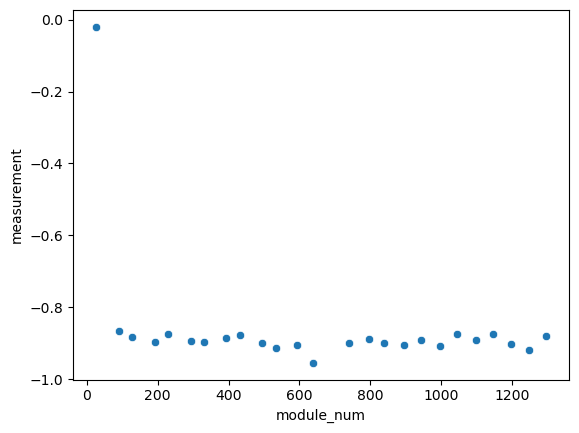

In [84]:
go_to_next()
plot_meas(mille_data)